In [1]:
print("D")

D


In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

In [ ]:
test_dir = "data/Test"
img_size = (224, 224)
batch_size = 32

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)



Found 3242 images belonging to 2 classes.


In [9]:
print(test_generator.class_indices)

{'Accident': 0, 'NonAccident': 1}


In [1]:
model = tf.keras.models.load_model("Models/accident_model.h5")

NameError: name 'tf' is not defined

In [11]:
pred_probs = model.predict(test_generator)
preds = (pred_probs > 0.45).astype(int).flatten()


true_labels = test_generator.classes
class_names = list(test_generator.class_indices.keys())

102/102 ━━━━━━━━━━━━━━━━━━━━ 23s 221ms/step


In [13]:
print("Class Names:", class_names)
print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, preds))

print("\nClassification Report:")
print(classification_report(true_labels, preds, target_names=class_names))

Class Names: ['Accident', 'NonAccident']

Confusion Matrix:
[[ 794  135]
 [  27 2286]]

Classification Report:
              precision    recall  f1-score   support

    Accident       0.97      0.85      0.91       929
 NonAccident       0.94      0.99      0.97      2313

    accuracy                           0.95      3242
   macro avg       0.96      0.92      0.94      3242
weighted avg       0.95      0.95      0.95      3242



In [ ]:
import matplotlib.pyplot as plt





plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

NameError: name 'train_generator' is not defined

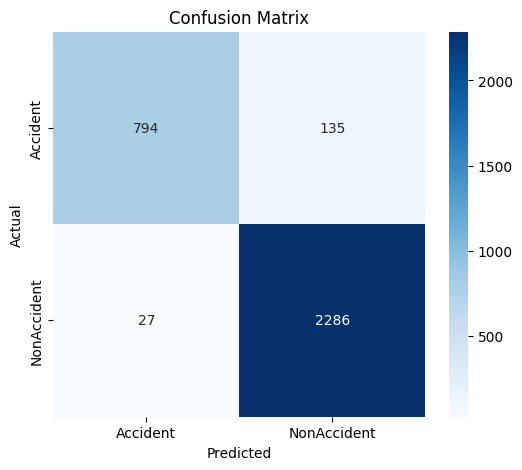

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, preds)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

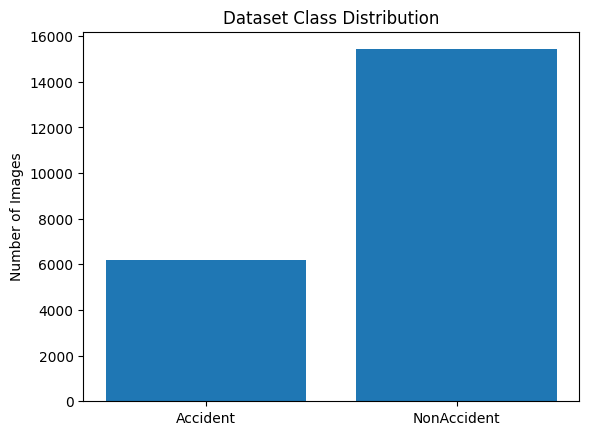

In [15]:
import matplotlib.pyplot as plt

labels = ['Accident','NonAccident']
values = [6191,15420]

plt.bar(labels, values)

plt.title("Dataset Class Distribution")
plt.ylabel("Number of Images")

plt.show()